In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.options.display.max_columns = None
#caricamento dataset
df = pd.read_csv('../data/heart.csv')

In [2]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [26]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [3]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,1025.0,54.434146,9.072290,29.0,48.0,56.0,61.0,77.0
sex,1025.0,0.695610,0.460373,0.0,0.0,1.0,1.0,1.0
cp,1025.0,0.942439,1.029641,0.0,0.0,1.0,2.0,3.0
trestbps,1025.0,131.611707,17.516718,94.0,120.0,130.0,140.0,200.0
chol,1025.0,246.000000,51.592510,126.0,211.0,240.0,275.0,564.0
fbs,1025.0,0.149268,0.356527,0.0,0.0,0.0,0.0,1.0
restecg,1025.0,0.529756,0.527878,0.0,0.0,1.0,1.0,2.0
thalach,1025.0,149.114146,23.005724,71.0,132.0,152.0,166.0,202.0
exang,1025.0,0.336585,0.472772,0.0,0.0,0.0,1.0,1.0
oldpeak,1025.0,1.071512,1.175053,0.0,0.0,0.8,1.8,6.2


In [5]:
df['target'].value_counts()

target
1    526
0    499
Name: count, dtype: int64

In [6]:
#controllo valori nulli
print("Valori nulli per colonna:")
print(df.isnull().sum())

#controllo duplicati
num_duplicates = df.duplicated().sum()
print(f"\nNumero di righe duplicate: {num_duplicates}")

#controllo zeri anomali su parametri continui
zero_chol = (df['chol'] == 0).sum()
zero_trestbps = (df['trestbps'] == 0).sum()
print(f"Pazienti con colesterolo = 0: {zero_chol}")
print(f"Pazienti con pressione a riposo = 0: {zero_trestbps}")

Valori nulli per colonna:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Numero di righe duplicate: 723
Pazienti con colesterolo = 0: 0
Pazienti con pressione a riposo = 0: 0


In [7]:
#rimozione dei duplicati, tengo il primo record
df_clean = df.drop_duplicates().copy()

print(f"Dimensioni originarie: {df.shape}")
print(f"Nuove dimensioni dopo la pulizia: {df_clean.shape}")
print(f"Pazienti unici rimasti: {len(df_clean)}")

Dimensioni originarie: (1025, 14)
Nuove dimensioni dopo la pulizia: (302, 14)
Pazienti unici rimasti: 302


In [8]:
#distribuzione del target sui dati non duplicati
print(df_clean['target'].value_counts())
print("\nPercentuali:")
print(df_clean['target'].value_counts(normalize=True) * 100)

target
1    164
0    138
Name: count, dtype: int64

Percentuali:
target
1    54.304636
0    45.695364
Name: proportion, dtype: float64


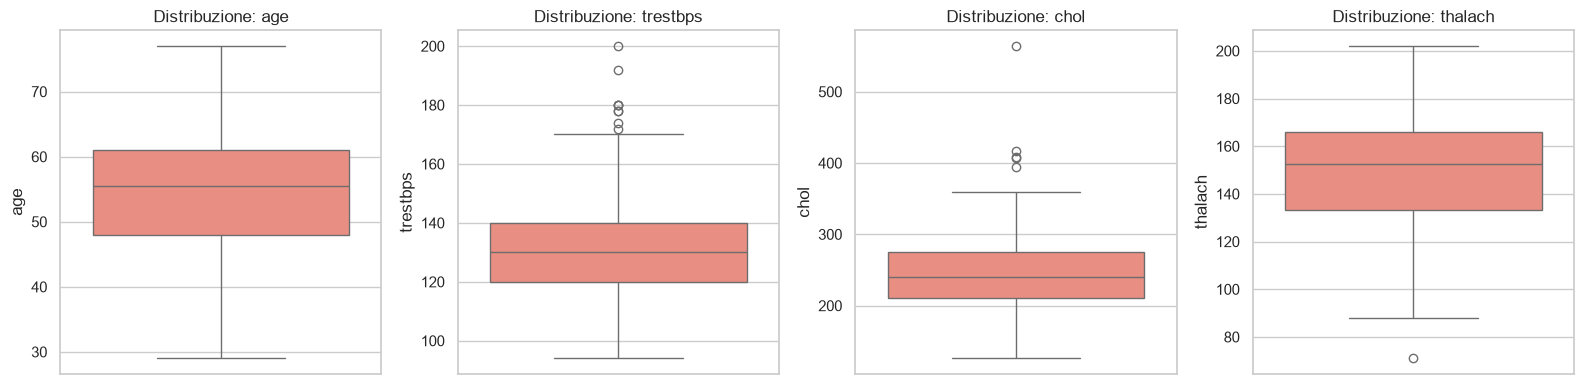

In [9]:
continuous_features = ['age', 'trestbps', 'chol', 'thalach']

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for idx, col in enumerate(continuous_features):
    sns.boxplot(y=df_clean[col], ax=axes[idx], color='salmon')
    axes[idx].set_title(f'Distribuzione: {col}')

plt.tight_layout()
plt.show()

In [10]:
def check_outliers_iqr(dataframe, column_name):
    q25 = dataframe[column_name].quantile(0.25)
    q75 = dataframe[column_name].quantile(0.75)
    iqr = q75 - q25
    upper_bound = q75 + 1.5 * iqr
    lower_bound = q25 - 1.5 * iqr

    outliers = dataframe.loc[(dataframe[column_name] < lower_bound) | (dataframe[column_name] > upper_bound)]
    print(f"[{column_name}] Soglia sup: {upper_bound:.1f} | Outliers trovati: {len(outliers)}")
    return outliers

outliers_chol = check_outliers_iqr(df_clean, 'chol')
outliers_trestbps = check_outliers_iqr(df_clean, 'trestbps')

[chol] Soglia sup: 370.4 | Outliers trovati: 5
[trestbps] Soglia sup: 170.0 | Outliers trovati: 9


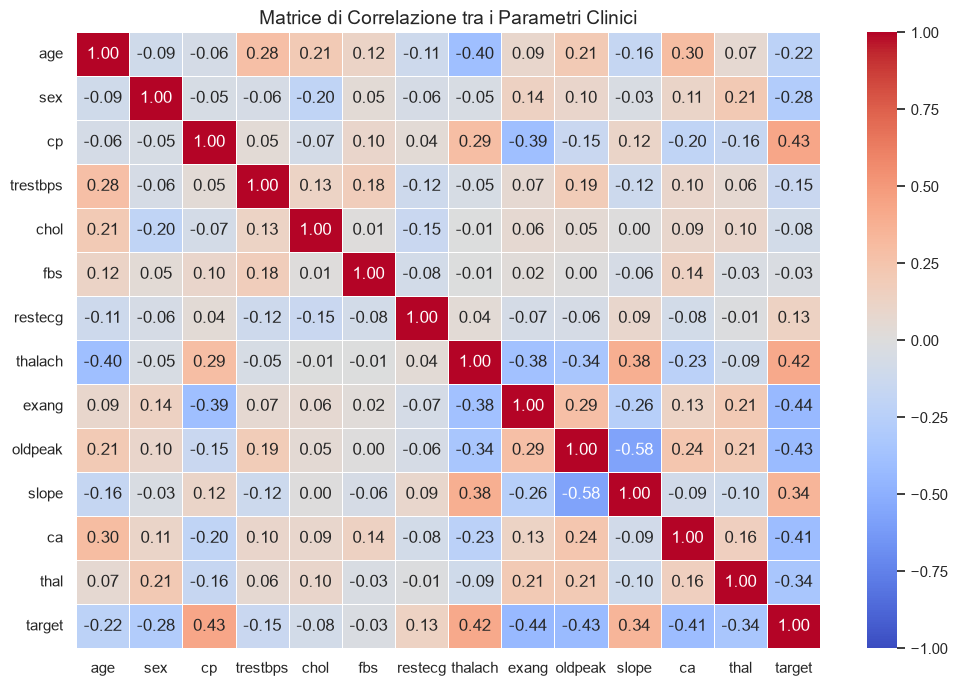

Correlazione delle variabili con il Target:
target      1.000000
cp          0.432080
thalach     0.419955
slope       0.343940
restecg     0.134874
fbs        -0.026826
chol       -0.081437
trestbps   -0.146269
age        -0.221476
sex        -0.283609
thal       -0.343101
ca         -0.408992
oldpeak    -0.429146
exang      -0.435601
Name: target, dtype: float64


In [11]:
plt.figure(figsize=(12, 8))
corr_matrix = df_clean.corr()

#visualizzazione matrice con valori numerici annotati
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)
plt.title("Matrice di Correlazione tra i Parametri Clinici", fontsize=14)
plt.show()

#ordinamento dei fattori più correlati rispetto alla diagnosi
print("Correlazione delle variabili con il Target:")
print(corr_matrix['target'].sort_values(ascending=False))

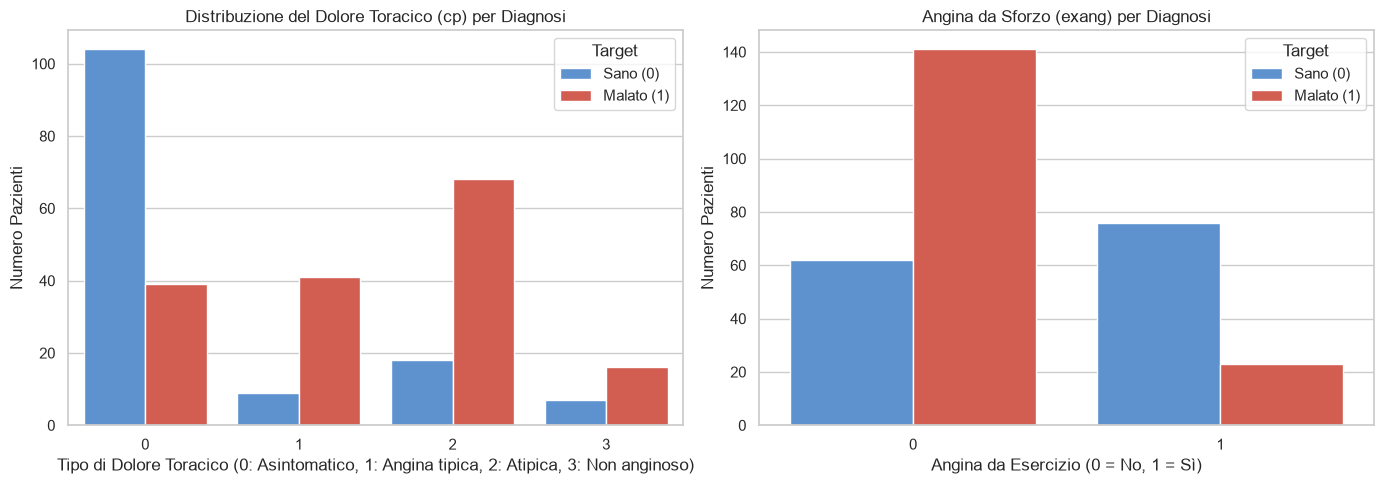

In [12]:
#creazione canvas per i due grafici
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

#cp vs Target
sns.countplot(
    data=df_clean,
    x='cp',
    hue='target',
    palette=['#4a90e2', '#e74c3c'],
    ax=axes[0]
)
axes[0].set_title("Distribuzione del Dolore Toracico (cp) per Diagnosi", fontsize=12)
axes[0].set_xlabel("Tipo di Dolore Toracico (0: Asintomatico, 1: Angina tipica, 2: Atipica, 3: Non anginoso)")
axes[0].set_ylabel("Numero Pazienti")
axes[0].legend(title="Target", labels=["Sano (0)", "Malato (1)"])

#exang vs Target
sns.countplot(
    data=df_clean,
    x='exang',
    hue='target',
    palette=['#4a90e2', '#e74c3c'],
    ax=axes[1]
)
axes[1].set_title("Angina da Sforzo (exang) per Diagnosi", fontsize=12)
axes[1].set_xlabel("Angina da Esercizio (0 = No, 1 = Sì)")
axes[1].set_ylabel("Numero Pazienti")
axes[1].legend(title="Target", labels=["Sano (0)", "Malato (1)"])

plt.tight_layout()
plt.show()

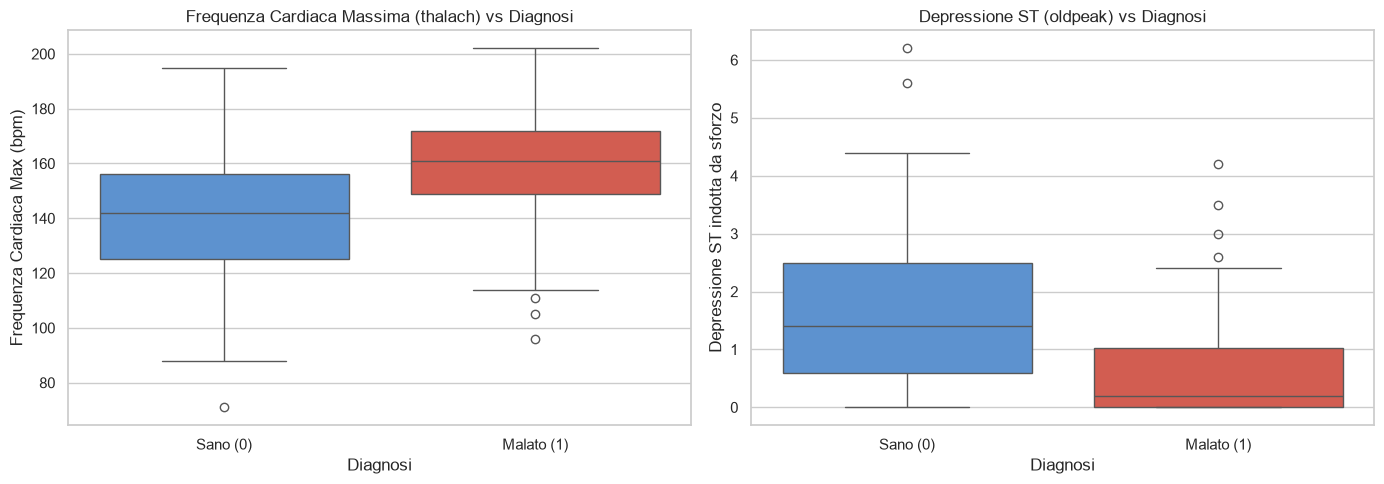

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

#thalach vs Target
sns.boxplot(
    data=df_clean,
    x='target',
    y='thalach',
    hue='target',
    palette=['#4a90e2', '#e74c3c'],
    legend=False,
    ax=axes[0]
)
axes[0].set_title("Frequenza Cardiaca Massima (thalach) vs Diagnosi", fontsize=12)
axes[0].set_xlabel("Diagnosi")
axes[0].set_ylabel("Frequenza Cardiaca Max (bpm)")
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(["Sano (0)", "Malato (1)"])

#oldpeak vs Target
sns.boxplot(
    data=df_clean,
    x='target',
    y='oldpeak',
    hue='target',
    palette=['#4a90e2', '#e74c3c'],
    legend=False,
    ax=axes[1]
)
axes[1].set_title("Depressione ST (oldpeak) vs Diagnosi", fontsize=12)
axes[1].set_xlabel("Diagnosi")
axes[1].set_ylabel("Depressione ST indotta da sforzo")
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(["Sano (0)", "Malato (1)"])

plt.tight_layout()
plt.show()

In [15]:
#salvataggio dataset pulito
df_clean.to_csv('../data/heart_cleaned.csv', index=False)
print(f"Dataset pulito salvato con successo! Dimensioni: {df_clean.shape}")

Dataset pulito salvato con successo! Dimensioni: (302, 14)


In [16]:
#calcolo mediana e media raggruppate per diagnosi
confronto_statistico = df_clean.groupby('target')[['thalach', 'oldpeak']].agg(['median', 'mean']).round(2)
print("Statistiche descrittive (Mediana e Media) per diagnosi:")
print(confronto_statistico)

Statistiche descrittive (Mediana e Media) per diagnosi:
       thalach         oldpeak      
        median    mean  median  mean
target                              
0        142.0  139.10     1.4  1.59
1        161.0  158.38     0.2  0.59
